In [ ]:
!pip install -q "jittor==1.3.11.0"

In [1]:
import os

# 不允许程序寻找GPU
os.environ["CUDA_VISIBLE_DEVICES"] = ""

import jittor as jt
from jittor import nn

# 明确使用CPU
jt.flags.use_cuda = 0

print("Jittor版本：", jt.__version__)
print("计算设备：CPU")

x = jt.ones([2, 3])
y = x * 2

print("x：")
print(x)

print("y：")
print(y)

print("Jittor CPU环境检查成功")

[i 0902 12:56:21.377612 56 lock.py:85] Create lock file:/root/.cache/jittor/jt1.3.11/g++11.4.0/py3.12.13/Linux-6.12.90+x7d/AMDEPYC7B12/b63e/jittor.lock
[i 0902 12:56:21.388049 56 compiler.py:955] Jittor(1.3.11.0) src: /usr/local/lib/python3.12/dist-packages/jittor
[i 0902 12:56:21.390248 56 compiler.py:956] g++ at /usr/bin/g++(11.4.0)
[i 0902 12:56:21.390371 56 compiler.py:957] cache_path: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.12.13/Linux-6.12.90+x7d/AMDEPYC7B12/b63e/default
[i 0902 12:56:21.404991 56 __init__.py:412] Found addr2line(2.38) at /usr/bin/addr2line.
[i 0902 12:56:21.439919 56 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.12.13/Linux-6.12.90+x7d/AMDEPYC7B12/b63e/default/jit
[i 0902 12:56:21.440178 56 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.12.13/Linux-6.12.90+x7d/AMDEPYC7B12/b63e/default/obj_files
[i 0902 12:56:21.440321 56 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.12

[i 0902 12:56:27.832564 20 log.cc:351] Load log_sync: 1
[i 0902 12:56:40.863589 20 __init__.py:227] Total mem: 31.35GB, using 10 procs for compiling.


[i 0902 12:58:04.325593 20 log.cc:351] Load log_sync: 1
[i 0902 12:58:04.326611 20 jit_compiler.cc:28] Load cc_path: /usr/bin/g++


Compiling jittor_core(150/150) used: 83.105s eta: 0.000s


[i 0902 12:58:08.105903 20 __init__.py:412] Found mpicc(4.1.2) at /usr/bin/mpicc.
[i 0902 12:58:08.122022 20 compiler.py:33] Create cache dir: /root/.cache/jittor/jt1.3.11/g++11.4.0/py3.12.13/Linux-6.12.90+x7d/AMDEPYC7B12/b63e/default/custom_ops


...

[i 0902 12:58:11.360765 20 compiler.py:33] Create cache dir: /root/.cache/jittor/mkl
[i 0902 12:58:11.362440 20 compile_extern.py:73] Downloading mkl...


10.5MB [00:03, 3.45MB/s]                            


Use time: 18.51 ms per iteration.
Example passed on CPU.
Compiling gen_ops_mkl_conv_mkl_conv_backward_x_mkl_test_mkl____hash611803(7/7) used: 4.723s eta: 0.000s
Jittor版本： 1.3.11.0
计算设备：CPU
x：



Compiling Operators(3/3) used: 2.31s eta:    0s 


jt.Var([[1. 1. 1.]
        [1. 1. 1.]], dtype=float32)
y：
jt.Var([[2. 2. 2.]
        [2. 2. 2.]], dtype=float32)
Jittor CPU环境检查成功


In [2]:
import pandas as pd
import numpy as np

train_path="/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_train.csv"
test_path="/kaggle/input/datasets/oddrationale/mnist-in-csv/mnist_test.csv"

train_df=pd.read_csv(train_path)
test_df=pd.read_csv(test_path)

x_train=train_df.iloc[:,1:].values.astype("float32")
y_train=train_df.iloc[:,0].values.astype("int32")

x_test=test_df.iloc[:,1:].values.astype("float32")
y_test=test_df.iloc[:,0].values.astype("int32")

x_train=x_train.reshape(-1,1,28,28)
x_test=x_test.reshape(-1,1,28,28)

x_train=x_train/255.0
x_test=x_test/255.0

print("训练图片形状: ",x_train.shape)
print("训练标签形状: ",y_train.shape)
print("测试图片形状: ",x_test.shape)
print("测试标签形状: ",y_test.shape)
print("像素范围: ",x_train.min(),"到",x_train.max())
print("前10个标签: ",y_train[:10])


训练图片形状:  (60000, 1, 28, 28)
训练标签形状:  (60000,)
测试图片形状:  (10000, 1, 28, 28)
测试标签形状:  (10000,)
像素范围:  0.0 到 1.0
前10个标签:  [5 0 4 1 9 2 1 3 1 4]


In [3]:
from jittor.dataset import Dataset

class MNISTCSVDataset(Dataset):
    def __init__(self,images,labels,batch_size=64,shuffle=True):
        super().__init__()

        self.images=images
        self.labels=labels

        self.set_attrs(
            total_len=len(labels),
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=0
        )

    def __getitem__(self,index):
        image=self.images[index]
        label=self.labels[index]

        return image,label

train_loader=MNISTCSVDataset(
    x_train,
    y_train,
    batch_size=64,
    shuffle=True
)

test_loader=MNISTCSVDataset(
    x_test,
    y_test,
    batch_size=64,
    shuffle=False
)

images,labels=next(iter(train_loader))

print("一个批次的图片形状: ",images.shape)
print("一个批次的标签形状: ",labels.shape)
print("前10个标签: ",labels[:10])


    

一个批次的图片形状:  [64,1,28,28,]
一个批次的标签形状:  [64,]
前10个标签:  jt.Var([1 4 9 5 9 7 2 1 9 2], dtype=int32)


In [4]:
import jittor as jt
from jittor import nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1=nn.Conv(
            in_channels=1,
            out_channels=16,
            kernel_size=3,
            padding=1
        )

        self.conv2=nn.Conv(
            in_channels=16,
            out_channels=32,
            kernel_size=3,
            padding=1
        )

        self.relu=nn.ReLU()

        self.pool=nn.Pool(
            kernel_size=2,
            stride=2,
            op="maximum"
        )

        self.fc=nn.Linear(32*7*7,10)

    def execute(self,x):
        x=self.conv1(x)
        x=self.relu(x)
        x=self.pool(x)

        x=self.conv2(x)
        x=self.relu(x)
        x=self.pool(x)

        x=x.reshape([x.shape[0],-1])

        x=self.fc(x)

        return x

model=SimpleCNN()
print(model)

SimpleCNN(
    conv1: Conv(1, 16, (3, 3), (1, 1), (1, 1), (1, 1), 1, float32[16,], None, None, Kw=None, fan=None, i=None, bound=None)
    conv2: Conv(16, 32, (3, 3), (1, 1), (1, 1), (1, 1), 1, float32[32,], None, None, Kw=None, fan=None, i=None, bound=None)
    relu: relu()
    pool: Pool((2, 2), (2, 2), (0, 0), dilation=None, return_indices=None, ceil_mode=False, count_include_pad=False, op=maximum, item=None)
    fc: Linear(1568, 10, float32[10,], None)
)


In [5]:
x=images

print("原始输入: ",x.shape)

x=model.conv1(x)
print("经过 conv1: ",x.shape)

x=model.relu(x)
x=model.pool(x)
print("经过第一次池化: ",x.shape)

x=model.conv2(x)
print("经过 conv2:",x.shape)

x=model.relu(x)
x=model.pool(x)
print("经过第二次池化: ",x.shape)

x=x.reshape([x.shape[0],-1])
print("展开以后: ",x.shape)

x=model.fc(x)
print("最终输出: ",x.shape)

原始输入:  [64,1,28,28,]
经过 conv1:  [64,16,28,28,]
经过第一次池化:  [64,16,14,14,]
经过 conv2: [64,32,14,14,]
经过第二次池化:  [64,32,7,7,]
展开以后:  [64,1568,]
最终输出:  [64,10,]


In [7]:
optimizer=nn.Adam(
    model.parameters(),
    lr=0.001
)

model.train()

predictions=model(images)

loss_before=nn.cross_entropy_loss(
    predictions,
    labels
)

loss_before_value=float(loss_before.item())

optimizer.step(loss_before)

predictions_after=model(images)

loss_after=nn.cross_entropy_loss(
    predictions_after,
    labels
)

loss_after_value=float(loss_after.item())

print("更新前 Loss: ",loss_before_value)
print("更新后 Loss: ",loss_after_value)


更新前 Loss:  2.251887559890747
更新后 Loss:  2.20232892036438


In [8]:
model=SimpleCNN()
print("经重新初始化模型")

经重新初始化模型


In [9]:
import time

optimizer=nn.Adam(
    model.parameters(),
    lr=0.001
)

num_epochs=3
epoch_losses=[]

start_time=time.time()

for epoch in range(num_epochs):
    model.train()

    running_loss=0.0
    batch_count=0

    for images,labels in train_loader:
        predictions=model(images)

        loss=nn.cross_entropy_loss(
            predictions,
            labels
        )

        loss_value=float(loss.item())

        optimizer.step(loss)

        running_loss+=loss_value
        batch_count+=1

        if batch_count%200==0:
            print(
                f"Epoch{epoch+1},"
                f"Batch{batch_count},"
                f"Loss:{loss_value:.4f}"
            )

    average_loss=running_loss/batch_count
    epoch_losses.append(average_loss)

    print(
        f"Epoch[{epoch+1}/{num_epochs}],"
        f"平均 Loss:{average_loss:.4f}"
    )

total_time=time.time()-start_time

print("训练完成")
print(f"总训练时间:{total_time:.2f}秒")
print("每轮平均Loss: ",epoch_losses)


Epoch1,Batch200,Loss:0.2973
Epoch1,Batch400,Loss:0.0980
Epoch1,Batch600,Loss:0.1246
Epoch1,Batch800,Loss:0.1360
Epoch[1/3],平均 Loss:0.2721
Epoch2,Batch200,Loss:0.0090
Epoch2,Batch400,Loss:0.0266
Epoch2,Batch600,Loss:0.0947
Epoch2,Batch800,Loss:0.0731
Epoch[2/3],平均 Loss:0.0819
Epoch3,Batch200,Loss:0.0304
Epoch3,Batch400,Loss:0.0370
Epoch3,Batch600,Loss:0.0618
Epoch3,Batch800,Loss:0.0186
Epoch[3/3],平均 Loss:0.0595
训练完成
总训练时间:39.99秒
每轮平均Loss:  [0.27211087151889257, 0.08185244676595463, 0.05950395870672813]


In [12]:
model.eval()

correct=0
total=0
test_loss_sum=0.0
test_batch_count=0

for test_images,test_labels in test_loader:
        outputs=model(test_images)

        test_loss=nn.cross_entropy_loss(
            outputs,
            test_labels
        )

        test_loss_sum+=float(test_loss.item())
        test_batch_count+=1

        output_array=outputs.numpy()
        label_array=test_labels.numpy()

        predicted_labels=output_array.argmax(axis=1)

        correct+=int((predicted_labels==label_array).sum())
        total+=len(label_array)

average_test_loss=test_loss_sum/test_batch_count
test_accuracy=correct/total*100

print("测试图片数量: ",total)
print("预测正确数量: ",correct)
print("测试集平均 Loss: ",average_test_loss)
print(f"测试准确率:{test_accuracy:.2f}%")


测试图片数量:  10000
预测正确数量:  9822
测试集平均 Loss:  0.04974176310910028
测试准确率:98.22%


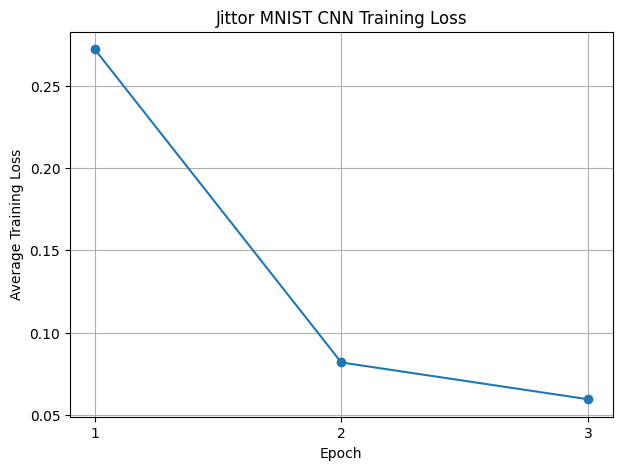

结果保存位置:  /kaggle/working/jittor_results
保存的文件: 
- training_history.csv
- trainig_history.csv
- jittor_mnist_cnn.pkl
- test_results.json
- loss_curve.png
- traing_history.csv


In [21]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

results_dir="/kaggle/working/jittor_results"
os.makedirs(results_dir,exist_ok=True)

model_path=os.path.join(
    results_dir,
    "jittor_mnist_cnn.pkl"
)

jt.save(
    model.state_dict(),
    model_path
)

history=pd.DataFrame({
    "epoch":range(1,len(epoch_losses)+1),
    "train_loss":epoch_losses
})

history.to_csv(
    os.path.join(results_dir,"training_history.csv"),
    index=False
)

metrics={
    "framework":"Jittor",
    "jittor_version":jt.__version__,
    "device":"CPU",
    "epochs":num_epochs,
    "batch_size":64,
    "learning_rate":0.001,
    "test_samples":int(total),
    "correct_predictions":int(correct),
    "wrong_predictions":int(total-correct),
    "test_loss":float(average_test_loss),
    "test_accuracy_percent":float(test_accuracy)
}

with open(
    os.path.join(results_dir,"test_results.json"),
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        metrics,
        file,
        ensure_ascii=False,
        indent=4
    )

plt.figure(figsize=(7,5))

plt.plot(
    range(1,len(epoch_losses)+1),
    epoch_losses,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Average Training Loss")
plt.title("Jittor MNIST CNN Training Loss")
plt.xticks(range(1,len(epoch_losses)+1))
plt.grid(True)

plt.savefig(
    os.path.join(results_dir,"loss_curve.png"),
    dpi=150, 
    bbox_inches="tight"
)

plt.show()

print("结果保存位置: ",results_dir)
print("保存的文件: ")

for filename in os.listdir(results_dir):
    print("-",filename)




                 

In [22]:
loaded_model = SimpleCNN()

parameters = jt.load(
    "/kaggle/working/jittor_results/jittor_mnist_cnn.pkl"
)

loaded_model.load_parameters(parameters)
loaded_model.eval()

print("模型参数加载成功")

模型参数加载成功


In [24]:
zip_path = "/kaggle/working/jittor_mnist_results.zip"

if os.path.exists(zip_path):
    os.remove(zip_path)

print("旧ZIP已删除")

旧ZIP已删除


In [25]:
!zip -r /kaggle/working/jittor_mnist_results.zip \
    /kaggle/working/jittor_results

  adding: kaggle/working/jittor_results/ (stored 0%)
  adding: kaggle/working/jittor_results/training_history.csv (deflated 13%)
  adding: kaggle/working/jittor_results/trainig_history.csv (deflated 13%)
  adding: kaggle/working/jittor_results/jittor_mnist_cnn.pkl (deflated 7%)
  adding: kaggle/working/jittor_results/test_results.json (deflated 40%)
  adding: kaggle/working/jittor_results/loss_curve.png (deflated 12%)
  adding: kaggle/working/jittor_results/traing_history.csv (deflated 13%)
